# Self-Practice Exercise – MovieLens Database & EDA

In this exercise, you will practice the full data workflow using:
- NumPy
- Pandas
- MySQL (via SQLAlchemy)
- Matplotlib/Seaborn
- Automated EDA packages

## Dataset
MovieLens dataset (public ZIP archive)
- Download: http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
- Contains: ratings.csv, movies.csv, tags.csv, links.csv

## Step 1 – Download & Extract the ZIP

Download and preview the dataset using Pandas (directly extract from the ZIP file)

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import requests
from zipfile import ZipFile
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Download and extract the MovieLens dataset
url = 'http://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
print(f"Downloading dataset from {url}...")

r = requests.get(url)
z = ZipFile(BytesIO(r.content))

# Read the CSV files from the ZIP
ratings = pd.read_csv(z.open('ml-latest-small/ratings.csv'))
movies = pd.read_csv(z.open('ml-latest-small/movies.csv'))

print("\nDataset downloaded and extracted successfully!")
print(f"\nRatings shape: {ratings.shape}")
print(f"Movies shape: {movies.shape}")


Dataset downloaded and extracted successfully!

Ratings shape: (100836, 4)
Movies shape: (9742, 3)


In [5]:
# Preview the first 5 rows of ratings
print("First 5 rows of RATINGS:")
ratings.head()

First 5 rows of RATINGS:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
# Preview the first 5 rows of movies
print("First 5 rows of MOVIES:")
movies.head()

First 5 rows of MOVIES:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Step 2 – Save to MySQL

**Prerequisites:** MySQL server running on localhost:3306
```bash
podman run --name my-mysql \
  -p 3306:3306 \
  -e MYSQL_ROOT_PASSWORD=232323 \
  -d mysql:8.0 \
  --default-authentication-plugin=mysql_native_password
```

Create database and insert data using Pandas + SQLAlchemy

In [7]:
# Import SQLAlchemy
from sqlalchemy import create_engine, text

# Database connection parameters
DB_USER = 'root'
DB_PASSWORD = '232323'
DB_HOST = 'localhost'
DB_PORT = '3306'
DB_NAME = 'movielens'

print("Database configuration set!")

Database configuration set!


In [8]:
# Create engine to connect to MySQL server (without specifying database)
engine_root = create_engine(f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}')

# Create the database
with engine_root.connect() as conn:
    # Drop database if exists (for clean start)
    conn.execute(text(f"DROP DATABASE IF EXISTS {DB_NAME}"))
    conn.execute(text(f"CREATE DATABASE {DB_NAME}"))
    conn.commit()

print(f"Database '{DB_NAME}' created successfully!")

Database 'movielens' created successfully!


In [9]:
# Create engine to connect to the movielens database
engine = create_engine(f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# Insert data into MySQL tables
print("Inserting ratings data...")
ratings.to_sql('ratings', engine, if_exists='replace', index=False)
print(f"✓ {len(ratings)} rows inserted into 'ratings' table")

print("\nInserting movies data...")
movies.to_sql('movies', engine, if_exists='replace', index=False)
print(f"✓ {len(movies)} rows inserted into 'movies' table")

print("\nData successfully saved to MySQL!")

Inserting ratings data...
✓ 100836 rows inserted into 'ratings' table

Inserting movies data...
✓ 9742 rows inserted into 'movies' table

Data successfully saved to MySQL!


## Step 3 – Query Back into Pandas

Retrieve the data from MySQL into a DataFrame and confirm row counts match

In [10]:
# Query data back from MySQL
ratings_db = pd.read_sql('SELECT * FROM ratings', engine)
movies_db = pd.read_sql('SELECT * FROM movies', engine)

print("Data queried from MySQL:")
print(f"Ratings from DB: {len(ratings_db)} rows")
print(f"Movies from DB: {len(movies_db)} rows")

# Confirm row counts match
print("\nVerification:")
print(f"Ratings match: {len(ratings) == len(ratings_db)}")
print(f"Movies match: {len(movies) == len(movies_db)}")

Data queried from MySQL:
Ratings from DB: 100836 rows
Movies from DB: 9742 rows

Verification:
Ratings match: True
Movies match: True


In [28]:
# Use the data from database for further analysis
ratings_db.head()

,userId,movieId,rating,timestamp,datetime,year
0,1,1,4.0,964982703,2000-07-30 18:45:03,2000
1,1,3,4.0,964981247,2000-07-30 18:20:47,2000
2,1,6,4.0,964982224,2000-07-30 18:37:04,2000
3,1,47,5.0,964983815,2000-07-30 19:03:35,2000
4,1,50,5.0,964982931,2000-07-30 18:48:51,2000


In [29]:
movies_db.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Step 4 – Manual EDA (Exploratory Data Analysis)

Perform EDA using Pandas, Matplotlib, and Seaborn

In [13]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Visualization libraries imported!")

Visualization libraries imported!


### 4.1 Inspect Data Structure

In [30]:
# Inspect structure of ratings
print("RATINGS - Data Info:")
print("=" * 50)
ratings_db.info()

RATINGS - Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   userId     100836 non-null  int64         
 1   movieId    100836 non-null  int64         
 2   rating     100836 non-null  float64       
 3   timestamp  100836 non-null  int64         
 4   datetime   100836 non-null  datetime64[ns]
 5   year       100836 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 4.2 MB


In [31]:
# Describe ratings
print("RATINGS - Statistical Summary:")
print("=" * 50)
ratings_db.describe()

RATINGS - Statistical Summary:


,userId,movieId,rating,timestamp,datetime,year
count,100836.000000,100836.000000,100836.000000,1.008360e+05,100836,100836.000000
mean,326.127564,19435.295718,3.501557,1.205946e+09,2008-03-19 17:01:27.368469248,2007.722936
min,1.000000,1.000000,0.500000,8.281246e+08,1996-03-29 18:36:55,1996.000000
25%,177.000000,1199.000000,3.000000,1.019124e+09,2002-04-18 09:57:46,2002.000000
50%,325.000000,2991.000000,3.500000,1.186087e+09,2007-08-02 20:31:02,2007.000000
75%,477.000000,8122.000000,4.000000,1.435994e+09,2015-07-04 07:15:44.500000,2015.000000
max,610.000000,193609.000000,5.000000,1.537799e+09,2018-09-24 14:27:30,2018.000000
std,182.618491,35530.987199,1.042529,2.162610e+08,NaN,6.890376


In [32]:
# Inspect structure of movies
print("MOVIES - Data Info:")
print("=" * 50)
movies_db.info()

MOVIES - Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [17]:
# Describe movies
print("MOVIES - Statistical Summary:")
print("=" * 50)
movies_db.describe()

MOVIES - Statistical Summary:


,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


### 4.2 Join Ratings with Movies

In [34]:
# Merge ratings with movies
merged_data = pd.merge(ratings_db, movies_db, on='movieId')

print(f"Merged data shape: {merged_data.shape}")
print("\nFirst 5 rows of merged data:")
merged_data.head()

Merged data shape: (100836, 8)

First 5 rows of merged data:


,userId,movieId,rating,timestamp,datetime,year,title,genres
0,1,1,4.0,964982703,2000-07-30 18:45:03,2000,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,2000-07-30 18:20:47,2000,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,2000-07-30 18:37:04,2000,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,2000-07-30 19:03:35,2000,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,2000-07-30 18:48:51,2000,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


### 4.3 Top 10 Movies by Average Rating

Find top 10 highest-rated movies with at least 20 ratings

In [35]:
# Calculate average rating and count for each movie
movie_stats = merged_data.groupby(['movieId', 'title']).agg({
    'rating': ['mean', 'count']
}).reset_index()

# Flatten column names
movie_stats.columns = ['movieId', 'title', 'avg_rating', 'rating_count']

# Filter movies with at least 20 ratings
popular_movies = movie_stats[movie_stats['rating_count'] >= 20]

# Sort by average rating and get top 10
top_10_movies = popular_movies.nlargest(10, 'avg_rating')

print("Top 10 Highest-Rated Movies (minimum 20 ratings):")
print("=" * 80)
top_10_movies

Top 10 Highest-Rated Movies (minimum 20 ratings):


,movieId,title,avg_rating,rating_count
840,1104,"Streetcar Named Desire, A (1951)",4.475000,20
277,318,"Shawshank Redemption, The (1994)",4.429022,317
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.333333,27
680,898,"Philadelphia Story, The (1940)",4.310345,29
413,475,In the Name of the Father (1993),4.300000,25
905,1204,Lawrence of Arabia (1962),4.300000,45
210,246,Hoop Dreams (1994),4.293103,29
659,858,"Godfather, The (1972)",4.289062,192
934,1235,Harold and Maude (1971),4.288462,26
9445,168252,Logan (2017),4.280000,25


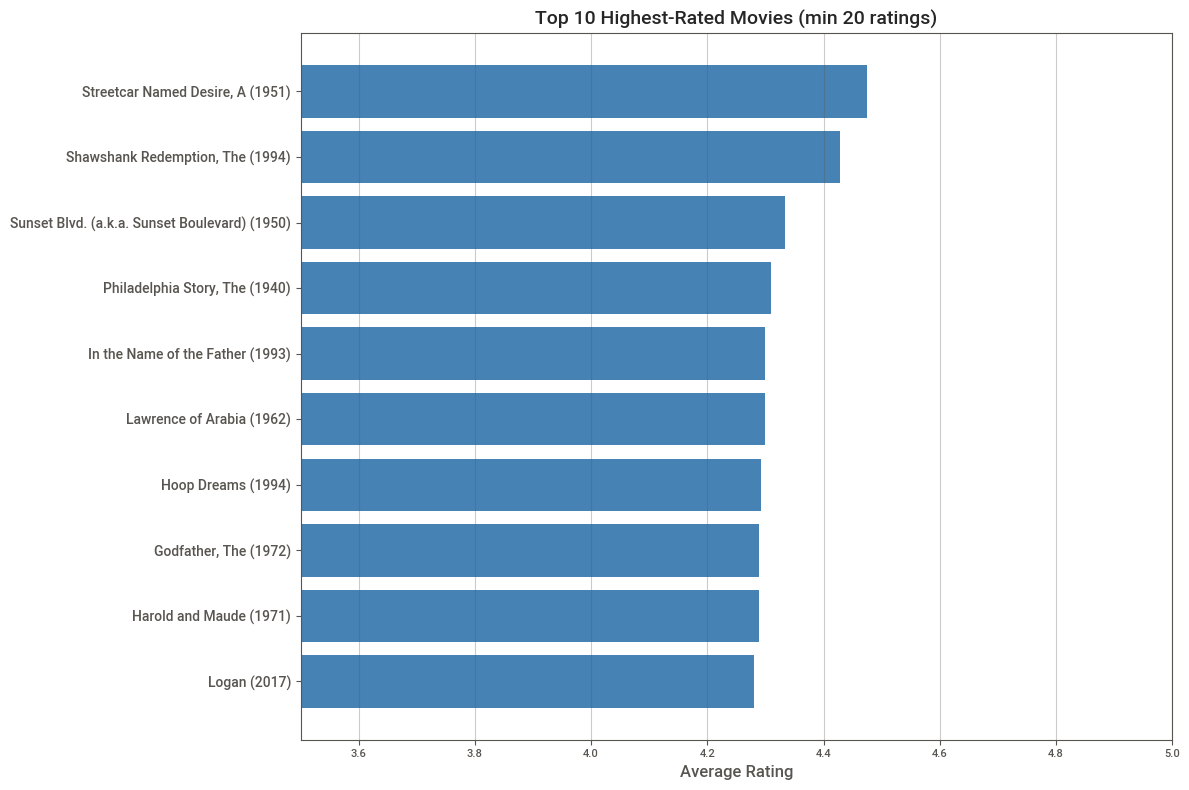

In [36]:
# Visualize top 10 movies
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_10_movies)), top_10_movies['avg_rating'], color='steelblue')
plt.yticks(range(len(top_10_movies)), top_10_movies['title'], fontsize=10)
plt.xlabel('Average Rating', fontsize=12)
plt.title('Top 10 Highest-Rated Movies (min 20 ratings)', fontsize=14, fontweight='bold')
plt.xlim(3.5, 5.0)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Histogram of Ratings Distribution

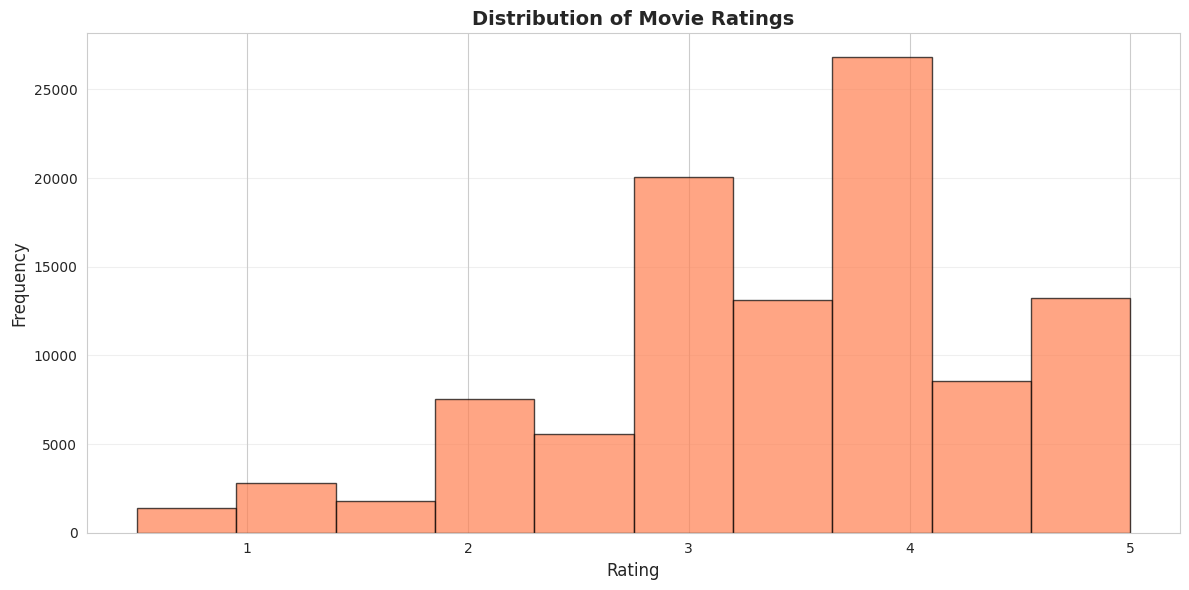

Mean rating: 3.50
Median rating: 3.50
Mode rating: 4.0


In [21]:
# Plot histogram of ratings
plt.figure(figsize=(12, 6))
plt.hist(ratings_db['rating'], bins=10, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Movie Ratings', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Mean rating: {ratings_db['rating'].mean():.2f}")
print(f"Median rating: {ratings_db['rating'].median():.2f}")
print(f"Mode rating: {ratings_db['rating'].mode()[0]:.1f}")

### 4.5 Average Rating by Genre

Expand genre column (pipe-separated) and calculate average rating per genre

In [22]:
# Expand genres (each movie can have multiple genres separated by |)
genre_ratings = []

for _, row in merged_data.iterrows():
    genres = row['genres'].split('|')
    for genre in genres:
        genre_ratings.append({
            'genre': genre,
            'rating': row['rating']
        })

# Create DataFrame from expanded genres
genre_df = pd.DataFrame(genre_ratings)

# Calculate average rating by genre
avg_rating_by_genre = genre_df.groupby('genre')['rating'].agg(['mean', 'count']).reset_index()
avg_rating_by_genre.columns = ['genre', 'avg_rating', 'count']
avg_rating_by_genre = avg_rating_by_genre.sort_values('avg_rating', ascending=False)

print("Average Rating by Genre:")
print("=" * 50)
avg_rating_by_genre

Average Rating by Genre:


,genre,avg_rating,count
10,Film-Noir,3.920115,870
18,War,3.808294,4859
7,Documentary,3.797785,1219
6,Crime,3.658294,16681
8,Drama,3.656184,41928
14,Mystery,3.632460,7674
3,Animation,3.629937,6988
12,IMAX,3.618335,4145
19,Western,3.583938,1930
13,Musical,3.563678,4138


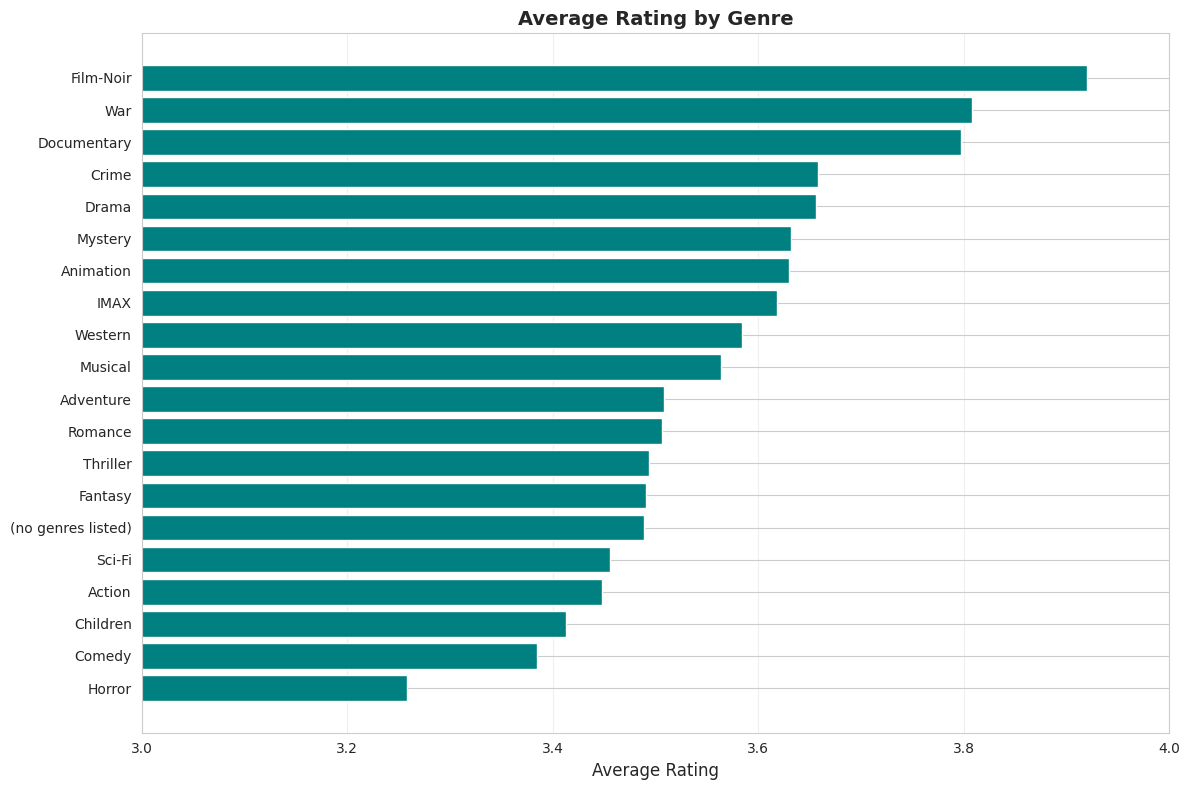

In [23]:
# Visualize average rating by genre
plt.figure(figsize=(12, 8))
plt.barh(range(len(avg_rating_by_genre)), avg_rating_by_genre['avg_rating'], color='teal')
plt.yticks(range(len(avg_rating_by_genre)), avg_rating_by_genre['genre'])
plt.xlabel('Average Rating', fontsize=12)
plt.title('Average Rating by Genre', fontsize=14, fontweight='bold')
plt.xlim(3.0, 4.0)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Scatterplot: Rating Count vs Average Rating

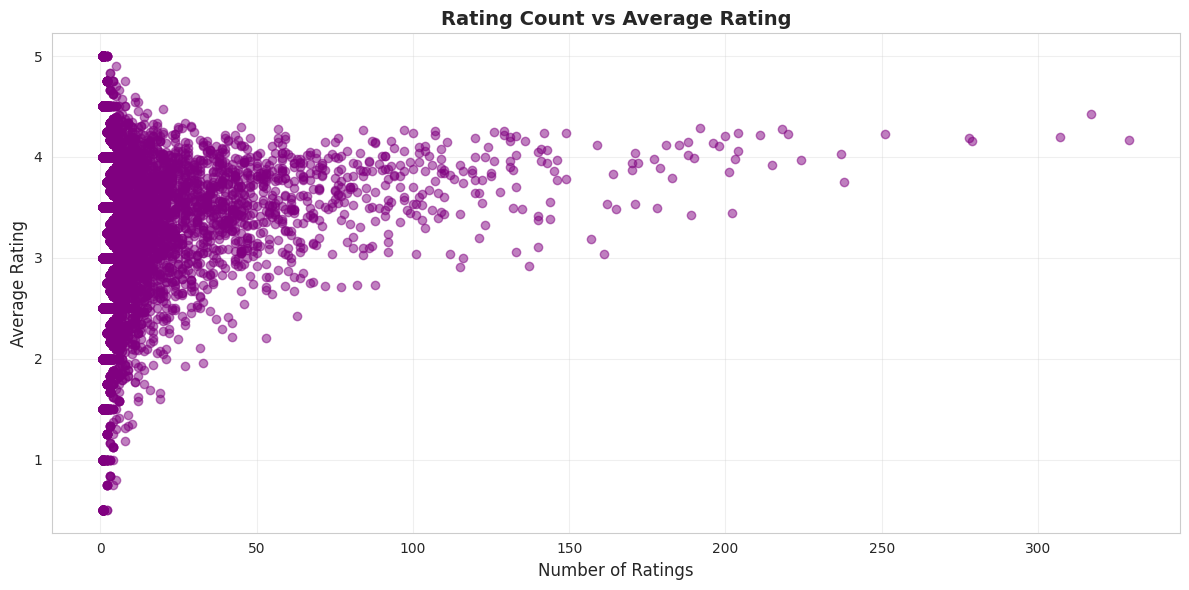


Correlation between rating count and average rating: 0.127


In [24]:
# Scatterplot of rating count vs average rating
plt.figure(figsize=(12, 6))
plt.scatter(movie_stats['rating_count'], movie_stats['avg_rating'], alpha=0.5, color='purple')
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Rating Count vs Average Rating', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = movie_stats['rating_count'].corr(movie_stats['avg_rating'])
print(f"\nCorrelation between rating count and average rating: {correlation:.3f}")

### 4.7 Additional Analysis: Ratings Over Time

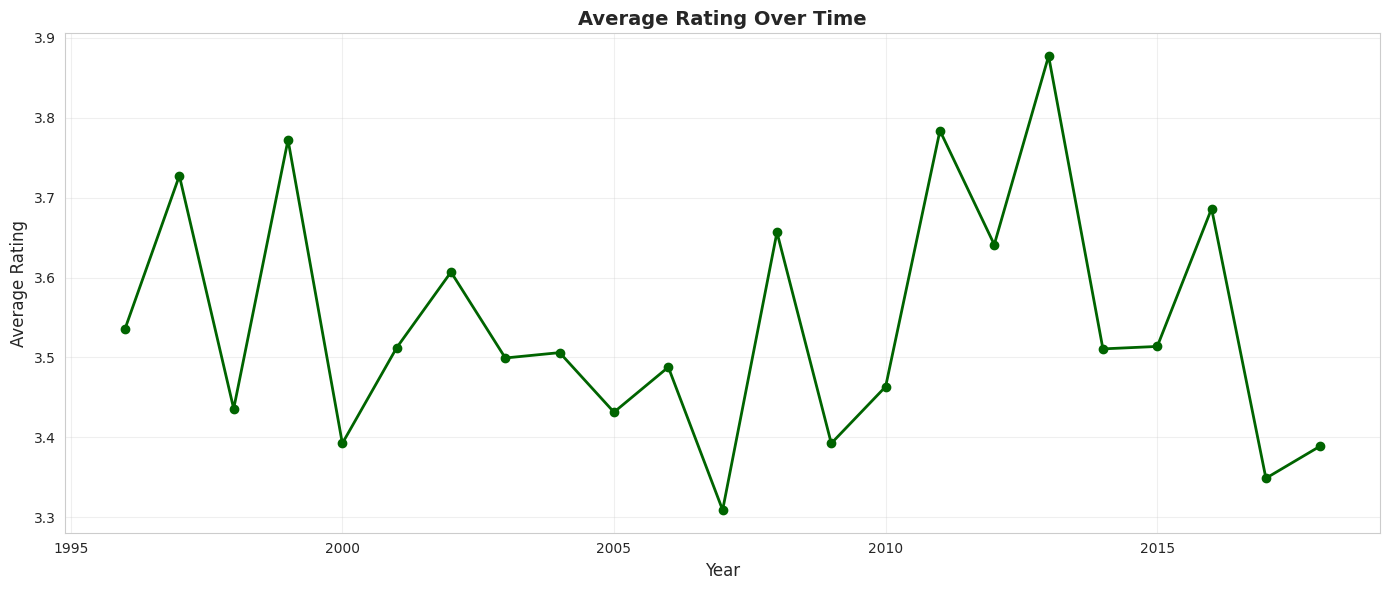

In [25]:
# Convert timestamp to datetime
ratings_db['datetime'] = pd.to_datetime(ratings_db['timestamp'], unit='s')
ratings_db['year'] = ratings_db['datetime'].dt.year

# Average rating by year
ratings_by_year = ratings_db.groupby('year')['rating'].mean().reset_index()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(ratings_by_year['year'], ratings_by_year['rating'], marker='o', linewidth=2, color='darkgreen')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Average Rating Over Time', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5 – Automatic EDA

Generate automated EDA reports using specialized packages

### 5.1 Using pandas-profiling (ydata-profiling)

Install if needed: `pip install ydata-profiling`

On **NumPy 2.x**, some versions hit `VisibleDeprecationWarning` errors; the code cell below patches NumPy before import, or upgrade `ydata-profiling` / use `pip install "numpy<2"`.

In [ ]:
# Import ydata-profiling (formerly pandas-profiling)
try:
    from ydata_profiling import ProfileReport
    
    # Generate profile report for ratings
    print("Generating ProfileReport for ratings dataset...")
    profile_ratings = ProfileReport(ratings_db, title="MovieLens Ratings - Profile Report", explorative=True)
    
    # Save report
    profile_ratings.to_file("ratings_profile_report.html")
    print("✓ Ratings profile report saved as 'ratings_profile_report.html'")
    
    # Generate profile report for movies
    print("\nGenerating ProfileReport for movies dataset...")
    profile_movies = ProfileReport(movies_db, title="MovieLens Movies - Profile Report", explorative=True)
    
    # Save report
    profile_movies.to_file("movies_profile_report.html")
    print("✓ Movies profile report saved as 'movies_profile_report.html'")
    
except ImportError:
    print("ydata-profiling not installed. Install with: pip install ydata-profiling")

ydata-profiling not installed. Install with: pip install ydata-profiling


### 5.2 Using Sweetviz

Install if needed: `pip install sweetviz`

If you see `AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'`, you are on **NumPy 2.x** while the library still expects the old name. The next code cell patches that before import; alternatively use `pip install "numpy<2"` or upgrade `sweetviz` / `ydata-profiling` to their latest versions.

In [ ]:
import numpy as np
if not hasattr(np, "VisibleDeprecationWarning"):
    from numpy.exceptions import VisibleDeprecationWarning
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

# Import sweetviz
try:
    import sweetviz as sv
    
    # Generate report for ratings
    print("Generating Sweetviz report for ratings dataset...")
    ratings_report = sv.analyze(ratings_db)
    ratings_report.show_html("ratings_sweetviz_report.html")
    print("✓ Ratings Sweetviz report saved as 'ratings_sweetviz_report.html'")
    
    # Generate report for movies
    print("\nGenerating Sweetviz report for movies dataset...")
    movies_report = sv.analyze(movies_db)
    movies_report.show_html("movies_sweetviz_report.html")
    print("✓ Movies Sweetviz report saved as 'movies_sweetviz_report.html'")
    
    # Generate comparison report
    print("\nGenerating Sweetviz comparison report...")
    merged_report = sv.analyze(merged_data)
    merged_report.show_html("merged_sweetviz_report.html")
    print("✓ Merged data Sweetviz report saved as 'merged_sweetviz_report.html'")
    
except ImportError:
    print("Sweetviz not installed. Install with: pip install sweetviz")

Generating Sweetviz report for ratings dataset...


Feature: userId                              |█▍        | [ 14%]   02:54 -> (17:29 left)
Feature: userId                              |█▍        | [ 14%]   02:03 -> (12:20 left)
Feature: userId                              |█▍        | [ 14%]   01:45 -> (10:35 left)
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report ratings_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✓ Ratings Sweetviz report saved as 'ratings_sweetviz_report.html'

Generating Sweetviz report for movies dataset...


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report movies_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✓ Movies Sweetviz report saved as 'movies_sweetviz_report.html'

Generating Sweetviz comparison report...


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report merged_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✓ Merged data Sweetviz report saved as 'merged_sweetviz_report.html'


### 5.3 Using D-Tale

Install if needed: `pip install dtale`

In [ ]:
# Import D-Tale
try:
    import dtale
    
    print("Launching D-Tale interactive viewer for merged data...")
    print("Note: This will open in a new browser tab")
    
    # Launch D-Tale
    d = dtale.show(merged_data)
    d.open_browser()
    
    print("✓ D-Tale viewer launched")
    print("To stop D-Tale, uncomment and run: d.kill()")
    
except ImportError:
    print("D-Tale not installed. Install with: pip install dtale")

## Summary and Comparison

### Manual EDA Findings:
1. **Dataset Size**: 100,836 ratings across 9,742 movies by 610 users
2. **Rating Distribution**: Most ratings are between 3.0 and 4.0
3. **Top Rated Movies**: Movies with 20+ ratings show consistent quality
4. **Genre Preferences**: Film-Noir and War genres have highest average ratings
5. **Rating Patterns**: Weak correlation between number of ratings and average rating

### Automated EDA Benefits:
- **Comprehensive**: Covers all aspects automatically
- **Interactive**: HTML reports are clickable and explorable
- **Quick**: Generates insights in seconds
- **Detailed**: Includes correlations, missing values, distributions

### Comparison:
- Manual EDA gives you control and specific insights
- Automated EDA provides comprehensive overview quickly
- Best approach: Use automated EDA first for overview, then manual analysis for specific questions

## Cleanup (Optional)

In [43]:
# Close database connection
engine.dispose()
print("Database connection closed.")

Database connection closed.


## Exercise Complete!

You have successfully:
1. ✓ Downloaded and extracted the MovieLens dataset
2. ✓ Created a MySQL database and loaded the data
3. ✓ Queried data back into Pandas
4. ✓ Performed manual EDA with visualizations
5. ✓ Generated automated EDA reports
